In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
np.random.seed(42)
n = 500

df = pd.DataFrame({
    'study_hours_per_day': np.random.uniform(1, 8, n),
    'attendance_percentage': np.random.uniform(60, 100, n),
    'assignments_completed': np.random.randint(5, 20, n),
    'previous_semester_marks': np.random.uniform(50, 95, n),
    'class_participation': np.random.uniform(3, 10, n)
})

df['final_performance_grade'] = (
    df['study_hours_per_day'] * 5 +
    df['attendance_percentage'] * 0.3 +
    df['assignments_completed'] * 2 +
    df['previous_semester_marks'] * 0.2 +
    df['class_participation'] * 3 +
    np.random.normal(0, 5, n)
).clip(0, 100)

df.to_csv('student_data.csv', index=False)
df.head()

,study_hours_per_day,attendance_percentage,assignments_completed,previous_semester_marks,class_participation,final_performance_grade
0,3.621781,87.926469,19,67.662210,8.161500,100.000000
1,7.655000,81.443855,16,71.597248,6.332127,100.000000
2,6.123958,72.381105,18,77.000925,5.631218,100.000000
3,5.190609,92.551801,12,63.124816,5.761334,99.617723
4,2.092130,87.389247,7,81.274185,6.216127,84.350333


In [3]:
print("Dataset Info:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())


df = df.fillna(df.mean())

print(f"\nShape: {df.shape}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   study_hours_per_day      500 non-null    float64
 1   attendance_percentage    500 non-null    float64
 2   assignments_completed    500 non-null    int32  
 3   previous_semester_marks  500 non-null    float64
 4   class_participation      500 non-null    float64
 5   final_performance_grade  500 non-null    float64
dtypes: float64(5), int32(1)
memory usage: 21.6 KB

Missing Values:
study_hours_per_day        0
attendance_percentage      0
assignments_completed      0
previous_semester_marks    0
class_participation        0
final_performance_grade    0
dtype: int64

Shape: (500, 6)


In [4]:
print(f"Duplicates before: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicates after: {df.duplicated().sum()}")
print(f"Final shape: {df.shape}")

Duplicates before: 0
Duplicates after: 0
Final shape: (500, 6)


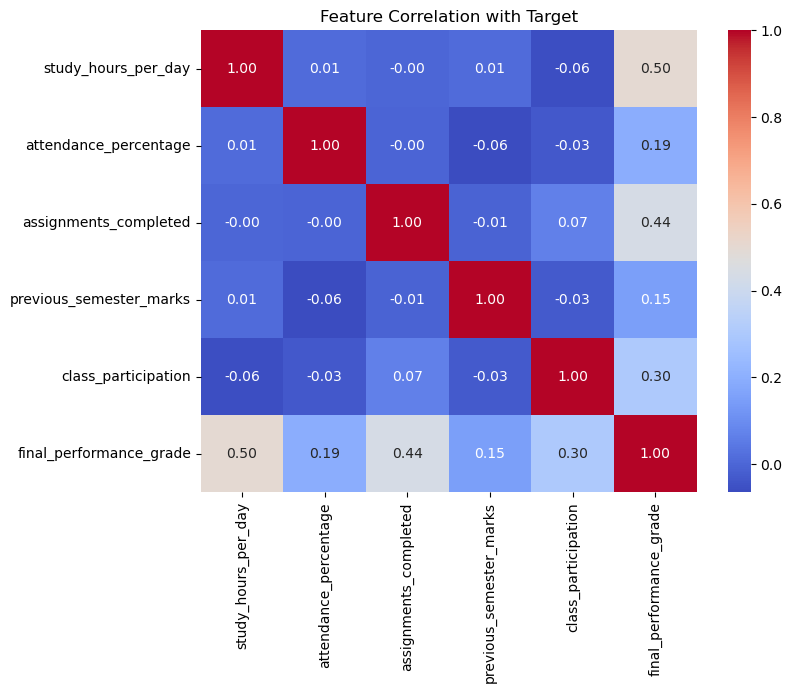

Selected Features: ['study_hours_per_day', 'attendance_percentage', 'assignments_completed', 'previous_semester_marks', 'class_participation']


In [5]:
X = df.drop('final_performance_grade', axis=1)
y = df['final_performance_grade']

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with Target')
plt.show()

print("Selected Features:", X.columns.tolist())

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (400, 5), Test: (100, 5)


In [7]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results:")
print(f"MAE: {lr_mae:.2f}")
print(f"R² Score: {lr_r2:.4f}")

Linear Regression Results:
MAE: 3.92
R² Score: 0.6289


In [8]:
dt_model = DecisionTreeRegressor(random_state=42, max_depth=10)
dt_model.fit(X_train_scaled, y_train)

dt_pred = dt_model.predict(X_test_scaled)
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Regressor Results:")
print(f"MAE: {dt_mae:.2f}")
print(f"R² Score: {dt_r2:.4f}")

Decision Tree Regressor Results:
MAE: 3.67
R² Score: 0.2853


In [9]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree'],
    'MAE': [lr_mae, dt_mae],
    'R² Score': [lr_r2, dt_r2]
}).sort_values('R² Score', ascending=False)

print("Model Comparison:")
print(results)

best_model = dt_model if dt_r2 > lr_r2 else lr_model
best_name = "Decision Tree" if dt_r2 > lr_r2 else "Linear Regression"
print(f"\nBest Model: {best_name} with R² = {max(lr_r2, dt_r2):.4f}")

Model Comparison:
               Model       MAE  R² Score
0  Linear Regression  3.917481   0.62892
1      Decision Tree  3.667533   0.28525

Best Model: Linear Regression with R² = 0.6289


In [11]:
if best_name == "Decision Tree":
    importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': dt_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    print(importances)